# 03: Analyze, map, and visualize

We will create a station-location map, one descriptive time-series figure, and a compact summary table. The map demonstrates a common spatial-data step: reprojecting geographic longitude/latitude into a local coordinate system in meters.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd

root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(root))
location_path = root / 'data/raw/site_location.json'
streamflow_path = root / 'data/processed/daily_streamflow.csv'

# Make this notebook runnable even if notebooks 01 and 02 have not been run.
if not location_path.exists() or not streamflow_path.exists():
    print('Required data files are missing; downloading and processing them now...')
    from src.download import download_streamflow
    from src.processing import make_processed_data
    download_streamflow()
    make_processed_data()

streamflow = pd.read_csv(streamflow_path, parse_dates=['date'])
location = json.loads(location_path.read_text(encoding='utf-8'))
location

{'site_no': '06730200',
 'site_name': 'BOULDER CREEK AT NORTH 75TH ST. NEAR BOULDER, CO',
 'latitude_wgs84': 40.051667,
 'longitude_wgs84': -105.178333,
 'coordinate_reference_system': 'EPSG:4326 (WGS 84)'}

## Reproject the streamgage location

USGS supplies longitude/latitude in WGS84 (`EPSG:4326`). Longitude and latitude are angles, so they are not appropriate for a local map scale in meters. For this Boulder-area locator map, transform to NAD83 / UTM zone 13N (`EPSG:26913`).

A projected coordinate system must be chosen for the place and purpose; do not copy this UTM zone to another region without checking it.

In [2]:
from pyproj import Transformer
transformer = Transformer.from_crs('EPSG:4326', 'EPSG:26913', always_xy=True)
easting_m, northing_m = transformer.transform(location['longitude_wgs84'], location['latitude_wgs84'])
print(f"WGS84: ({location['longitude_wgs84']:.5f}, {location['latitude_wgs84']:.5f})")
print(f'UTM 13N: ({easting_m:,.1f} m, {northing_m:,.1f} m)')

WGS84: (-105.17833, 40.05167)
UTM 13N: (484,789.1 m, 4,433,506.7 m)


## Create a location map

This offline locator map uses a projected coordinate grid rather than a third-party web basemap, so it is reproducible without another data service. The point comes from the USGS station metadata downloaded in notebook 01.

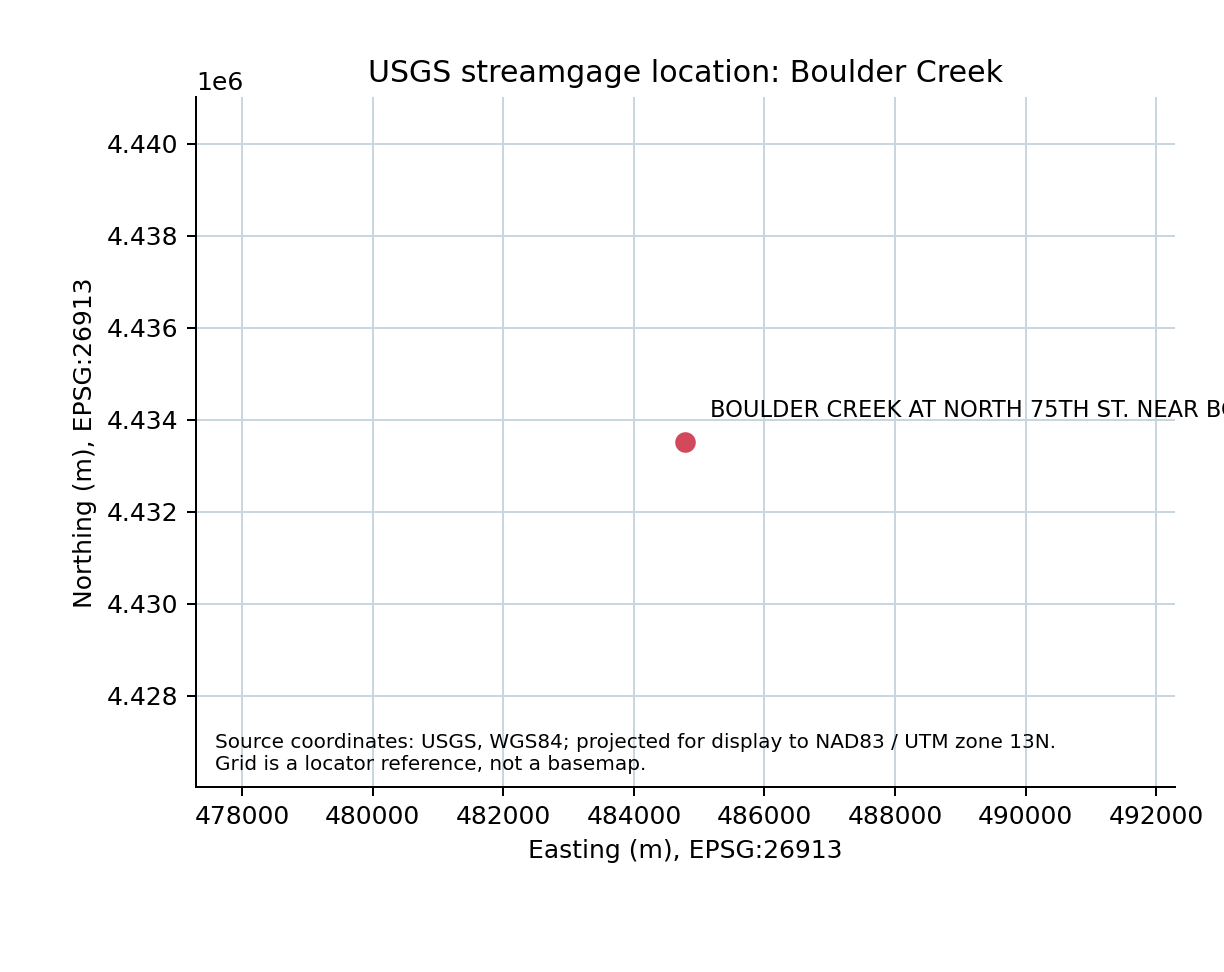

In [3]:
from src.plotting import create_location_map
create_location_map()
from IPython.display import Image, display
display(Image(filename=root / 'outputs/figures/boulder_creek_streamgage_location.png'))

## Make a small summary

Before plotting, calculate a few descriptive values. This lets a reader check the graph against the underlying data.

In [4]:
summary = streamflow['discharge_cfs'].agg(['count', 'min', 'median', 'mean', 'max']).to_frame('discharge_cfs')
summary.index.name = 'statistic'
summary.round(2)

,discharge_cfs
statistic,
count,153.00
min,17.40
median,82.30
mean,164.99
max,1030.00


## Make a quick exploratory plot

This cell is for looking. Notice high and low values, gaps, and whether the time range matches the documented query.

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(streamflow['date'], streamflow['discharge_cfs'], color='#1261A0')
ax.set(xlabel='Date', ylabel='Discharge (cubic feet per second)', title='Exploratory view: daily mean streamflow')
ax.spines[['top', 'right']].set_visible(False)
plt.show()

C:\Users\gekek\AppData\Local\Temp\ipykernel_37772\1020452192.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Create documented outputs

The project function writes the reusable figure and summary table to `outputs/`. Keeping this step in source code means a collaborator can reproduce it without copying notebook cells.

In [6]:
from src.plotting import create_outputs
summary = create_outputs()
summary.round(2)

,discharge_cfs
statistic,
count,153.00
min,17.40
median,82.30
mean,164.99
max,1030.00


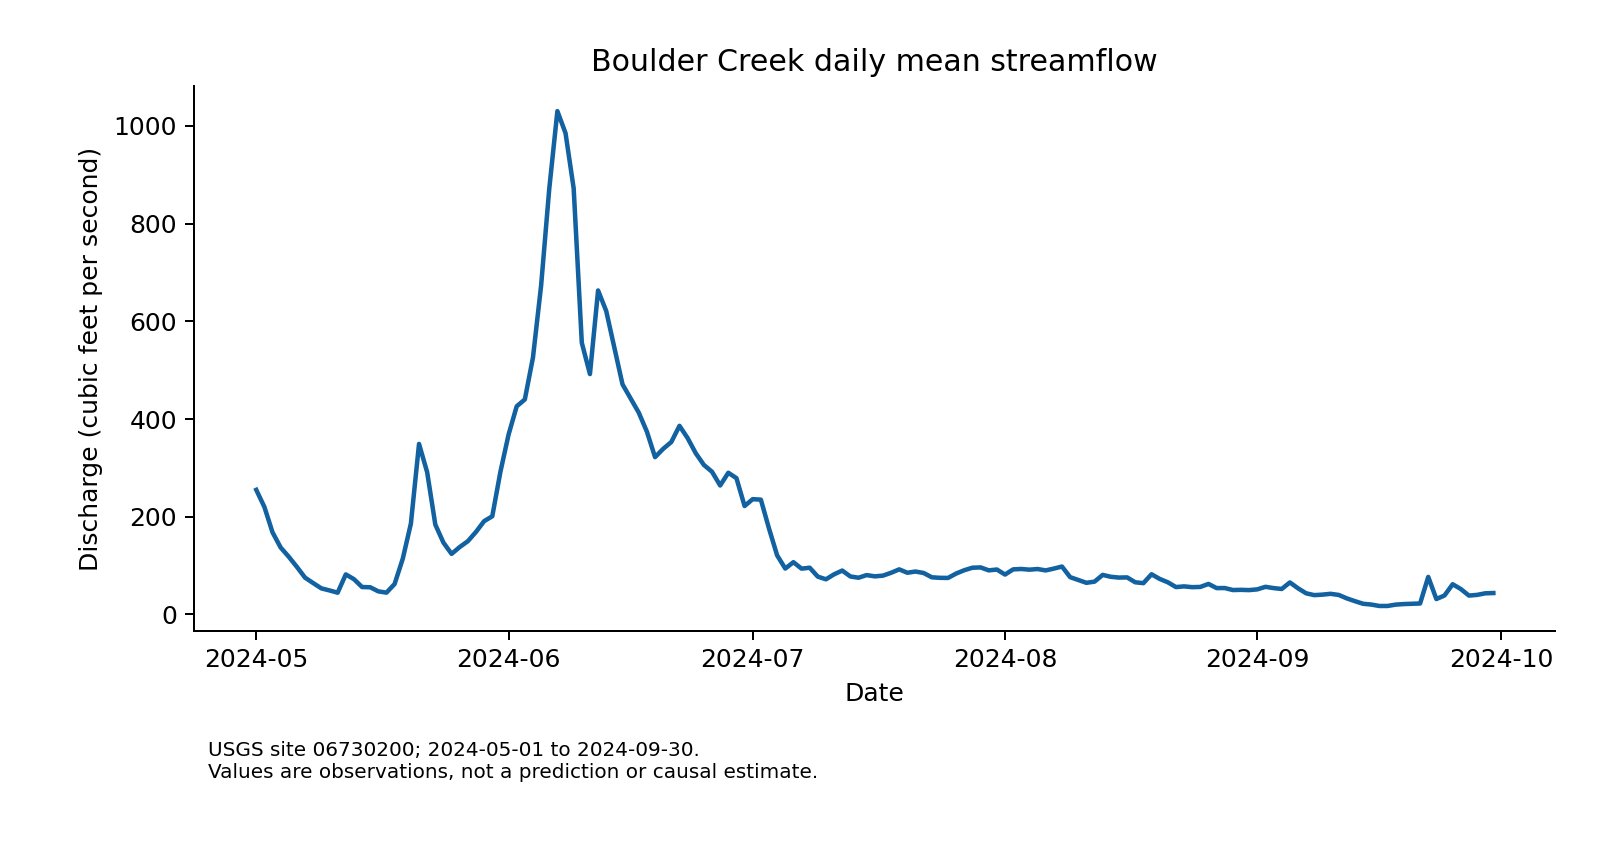

In [7]:
display(Image(filename=root / 'outputs/figures/boulder_creek_streamflow.png'))

### Checkpoint

Can a reader identify the station, date range, unit, coordinate system, and source from the outputs and surrounding documentation? What would you change before using them in a report?